# Phase 2 Final Submission  
# Comparing RNN, LSTM, and Transformer for Text Generation

## Project Goal

The goal of this project is to compare three neural network architectures:

1. Recurrent Neural Network (RNN)  
2. Long Short-Term Memory Network (LSTM)  
3. Transformer-based model  

The task is **next-word prediction** using the WikiText-2 dataset.

Given a sequence of words, each model learns to predict the next word.


Ai usage: i have use AI to generate function definitions, varibale definitions and for correcting the grammatical error as well as i have used to fix the grammar in markdown.

## Overall Pipeline and Steps

This project follows a structured end-to-end pipeline to ensure a fair comparison between RNN, LSTM, and Transformer models.

### Step 1: Dataset Loading
- Load the WikiText-2 dataset using Hugging Face
- Use predefined train, validation, and test splits
- Ensure no data leakage between splits


### Step 2: Text Preprocessing
- Convert all text to lowercase
- Perform word-level tokenization
- Remove empty lines
- Build a vocabulary from training data only
- Limit vocabulary size to the most frequent words
- Add special tokens (`<pad>`, `<unk>`)


### Step 3: Numerical Encoding
- Convert each word into its corresponding integer index
- Replace unseen words with `<unk>` token
- Represent the entire dataset as sequences of token IDs


### Step 4: Sequence Construction
- Create fixed-length input sequences (e.g., 100 tokens)
- Generate target sequences by shifting input by one position
- Example:
  - Input: "the cat sat on"
  - Target: "cat sat on the"


### Step 5: Dataset and DataLoader Creation
- Wrap sequences into a PyTorch Dataset class
- Use DataLoader to create batches
- Apply same batch size and sequence length for all models


### Step 6: Model Implementation
- Implement three models:
  - RNN (baseline recurrent model)
  - LSTM (gated recurrent model)
  - Transformer (attention-based model)
- Use embedding layers to convert tokens into dense vectors
- Keep architecture settings consistent where possible


### Step 7: Training Setup
- Use Cross-Entropy Loss for next-word prediction
- Use Adam optimizer for all models
- Train each model for the same number of epochs
- Apply gradient clipping for stability


### Step 8: Model Training
- Train each model on the training dataset
- Evaluate performance on validation dataset after each epoch
- Record:
  - Training loss
  - Validation loss
  - Training perplexity
  - Validation perplexity
  - Training time per epoch


### Step 9: Final Evaluation
- Evaluate all models on the test dataset
- Compute:
  - Test loss
  - Test perplexity


### Step 10: Performance Comparison
- Compare models based on:
  - Train, validation, and test perplexity
  - Number of parameters
  - Training time per epoch
- Create summary tables and visualizations


### Step 11: Visualization
- Plot:
  - Training vs validation loss curves
  - Training vs validation perplexity curves
  - Final test perplexity comparison (bar chart)
  - Training time comparison


### Step 12: Qualitative Evaluation
- Generate text using each trained model
- Compare:
  - Fluency
  - Coherence
  - Repetition patterns


### Step 13: Final Analysis
- Interpret quantitative results (perplexity, loss)
- Analyze training behavior and generalization
- Compare strengths and weaknesses of each model


### Step 14: Conclusion
- Summarize findings
- Identify best-performing model
- Highlight trade-offs between accuracy, efficiency, and architecture design

## 1. Import Libraries

In this section, we import all required libraries for data loading, preprocessing, model building, training, evaluation, and visualization.

In [1]:
import math
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from collections import Counter


/home/dsu.local/sanjeev.khatri/.conda/envs/tf310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 2. Set Random Seed and Device

We set a fixed random seed so that results are more reproducible.

We also check whether a GPU is available. If CUDA is available, training will use GPU; otherwise, it will use CPU.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 3. Load Dataset

We use the WikiText-2 dataset from Hugging Face.

This dataset is suitable because it contains real-world Wikipedia text and is commonly used for language modeling.

In [3]:
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-v1")

train_text = dataset["train"]["text"]
val_text = dataset["validation"]["text"]
test_text = dataset["test"]["text"]

print("Number of training lines:", len(train_text))
print("Number of validation lines:", len(val_text))
print("Number of test lines:", len(test_text))

Number of training lines: 36718
Number of validation lines: 3760
Number of test lines: 4358


## 4. Tokenization

Tokenization means splitting raw text into smaller units.

For this project, we use simple word-level tokenization.  
Each sentence is converted into lowercase words.

In [4]:
def tokenize_text(lines):
    """
    Convert raw text lines into a list of lowercase word tokens.

    Parameters:
        lines (list): List of text lines from the dataset.

    Returns:
        list: A list of word tokens.
    """
    tokens = []

    for line in lines:
        line = line.strip().lower()

        if line:
            words = line.split()
            tokens.extend(words)

    return tokens

In [5]:
train_tokens = tokenize_text(train_text)
val_tokens = tokenize_text(val_text)
test_tokens = tokenize_text(test_text)

print("Training tokens:", len(train_tokens))
print("Validation tokens:", len(val_tokens))
print("Test tokens:", len(test_tokens))

Training tokens: 2051910
Validation tokens: 213886
Test tokens: 241211


## 5. Build Vocabulary

The vocabulary maps each word to a unique integer.

We build the vocabulary only from the training data to avoid data leakage.

Special tokens:
- `<pad>`: used for padding if needed
- `<unk>`: used for unknown words not found in vocabulary

In [6]:
MAX_VOCAB_SIZE = 20000

def build_vocabulary(tokens, max_vocab_size):
    """
    Build word-to-index and index-to-word dictionaries.

    Parameters:
        tokens (list): Training tokens.
        max_vocab_size (int): Maximum vocabulary size.

    Returns:
        word_to_idx (dict): Maps words to integer IDs.
        idx_to_word (dict): Maps integer IDs back to words.
    """
    word_counter = Counter(tokens)

    most_common_words = word_counter.most_common(max_vocab_size - 2)

    word_to_idx = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word, count in most_common_words:
        word_to_idx[word] = len(word_to_idx)

    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    return word_to_idx, idx_to_word

In [7]:
word_to_idx, idx_to_word = build_vocabulary(train_tokens, MAX_VOCAB_SIZE)

vocab_size = len(word_to_idx)

print("Vocabulary size:", vocab_size)

Vocabulary size: 19999


## 6. Convert Words to Integer IDs

Neural networks cannot directly process words.  
So, each word is converted into its vocabulary index.

In [8]:
def tokens_to_ids(tokens, word_to_idx):
    """
    Convert a list of word tokens into integer token IDs.

    Parameters:
        tokens (list): List of word tokens.
        word_to_idx (dict): Word-to-index mapping.

    Returns:
        list: List of integer token IDs.
    """
    unk_id = word_to_idx["<unk>"]

    token_ids = []

    for token in tokens:
        token_id = word_to_idx.get(token, unk_id)
        token_ids.append(token_id)

    return token_ids

In [9]:
train_ids = tokens_to_ids(train_tokens, word_to_idx)
val_ids = tokens_to_ids(val_tokens, word_to_idx)
test_ids = tokens_to_ids(test_tokens, word_to_idx)

print("First 10 token IDs:", train_ids[:10])

First 10 token IDs: [10, 3816, 3879, 885, 10, 18216, 108, 3816, 92, 46]


## 7. Create Sequence Dataset

For next-word prediction, we create input and target sequences.

Example:

Input sequence:  
`the cat sat on`

Target sequence:  
`cat sat on the`

The model learns to predict the next token at each position.

In [10]:
# this class is created after multiple attempts of experimenting, and function creation for end-end 
# and program reusable concept i have created this class
class LanguageModelDataset(Dataset):
    """
    PyTorch Dataset for language modeling.

    Each sample contains:
    - x: input sequence
    - y: target sequence shifted by one token
    """

    def __init__(self, token_ids, sequence_length):
        self.token_ids = token_ids
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.token_ids) - self.sequence_length

    def __getitem__(self, index):
        x = self.token_ids[index : index + self.sequence_length]
        y = self.token_ids[index + 1 : index + self.sequence_length + 1]

        x = torch.tensor(x, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.long)

        return x, y

## 8. Create DataLoaders

DataLoaders divide the dataset into batches.

The same sequence length and batch size are used for RNN, LSTM, and Transformer to make the comparison fair.


In [37]:
SEQUENCE_LENGTH = 100
BATCH_SIZE = 32

train_dataset = LanguageModelDataset(train_ids, SEQUENCE_LENGTH)
val_dataset = LanguageModelDataset(val_ids, SEQUENCE_LENGTH)
test_dataset = LanguageModelDataset(test_ids, SEQUENCE_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 64119
Validation batches: 6680
Testing batches: 7534


## 9. Helper Functions

These functions are reused for all three models. They are created to remove the dupication of the code, they are created after 
multiple experimentation just like in industry level.

This avoids repeating code and makes the notebook cleaner.

In [12]:
def count_parameters(model):
    """
    Count the number of trainable parameters in a model.
    """
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def calculate_perplexity(loss):
    """
    Convert cross-entropy loss into perplexity.

    Lower perplexity means the model is better at predicting the next word.
    """
    if loss >= 20:
        return float("inf")

    return math.exp(loss)

In [13]:
def train_one_epoch(model, dataloader, optimizer, criterion, clip_value=1.0):
    """
    Train one model for one epoch.

    Parameters:
        model: PyTorch model
        dataloader: training dataloader
        optimizer: optimizer
        criterion: loss function
        clip_value: gradient clipping value

    Returns:
        average loss, perplexity, and training time
    """
    model.train()

    total_loss = 0
    start_time = time.time()

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(
            outputs.reshape(-1, outputs.size(-1)),
            y.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    perplexity = calculate_perplexity(average_loss)
    epoch_time = time.time() - start_time

    return average_loss, perplexity, epoch_time

In [14]:
def evaluate_model(model, dataloader, criterion):
    """
    Evaluate a model on validation or test data.

    Parameters:
        model: PyTorch model
        dataloader: validation or test dataloader
        criterion: loss function

    Returns:
        average loss and perplexity
    """
    model.eval()

    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            loss = criterion(
                outputs.reshape(-1, outputs.size(-1)),
                y.reshape(-1)
            )

            total_loss += loss.item()

    average_loss = total_loss / len(dataloader)
    perplexity = calculate_perplexity(average_loss)

    return average_loss, perplexity

In [15]:
def train_model(model, model_name, train_loader, val_loader, epochs, learning_rate):
    """
    Full training loop used for RNN, LSTM, and Transformer.

    Returns:
        trained model and training history
    """
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "model": model_name,
        "train_loss": [],
        "val_loss": [],
        "train_ppl": [],
        "val_ppl": [],
        "epoch_time": []
    }

    print(f"\nTraining {model_name}")
    print("=" * 60)

    for epoch in range(1, epochs + 1):
        train_loss, train_ppl, epoch_time = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_ppl = evaluate_model(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_ppl"].append(train_ppl)
        history["val_ppl"].append(val_ppl)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train PPL: {train_ppl:.2f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val PPL: {val_ppl:.2f} | "
            f"Time: {epoch_time:.2f}s"
        )

    return model, history

# 10. RNN Model

The RNN is the simplest recurrent model.

It processes tokens one step at a time and passes information through a hidden state.

Limitation:  
RNNs can struggle with long-term dependencies because older information may fade over time.

In [16]:
class RNNLanguageModel(nn.Module):
    """
    Vanilla RNN model for next-word prediction.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        rnn_output, hidden = self.rnn(embedded)

        rnn_output = self.dropout(rnn_output)

        logits = self.output_layer(rnn_output)

        return logits

# 11. LSTM Model

The LSTM improves over the basic RNN by using gates.

These gates help the model decide:
- what information to remember
- what information to forget
- what information to output

Because of this, LSTMs usually handle longer sequences better than vanilla RNNs.

In [17]:
class LSTMLanguageModel(nn.Module):
    """
    LSTM model for next-word prediction.
    """

    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        lstm_output, (hidden, cell) = self.lstm(embedded)

        lstm_output = self.dropout(lstm_output)

        logits = self.output_layer(lstm_output)

        return logits

# 12. Transformer Model

The Transformer uses self-attention instead of recurrence.

Self-attention allows the model to compare each token with other tokens in the sequence.

Because Transformers do not process tokens strictly one-by-one like RNNs, they are easier to parallelize and often perform better on language modeling tasks.

In [18]:
class PositionalEncoding(nn.Module):
    """
    Positional encoding adds information about word order.

    Since Transformer models do not have recurrence, they need positional encoding
    to understand the order of tokens in the sequence.
    """

    def __init__(self, embedding_dim, max_length=5000):
        super().__init__()

        positional_encoding = torch.zeros(max_length, embedding_dim)

        position = torch.arange(0, max_length).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embedding_dim, 2) *
            (-math.log(10000.0) / embedding_dim)
        )

        positional_encoding[:, 0::2] = torch.sin(position * div_term)
        positional_encoding[:, 1::2] = torch.cos(position * div_term)

        positional_encoding = positional_encoding.unsqueeze(0)

        self.register_buffer("positional_encoding", positional_encoding)

    def forward(self, x):
        sequence_length = x.size(1)

        x = x + self.positional_encoding[:, :sequence_length]

        return x

In [19]:
class TransformerLanguageModel(nn.Module):
    """
    Small Transformer encoder model for next-word prediction.
    """

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        num_heads,
        hidden_dim,
        num_layers,
        dropout
    ):
        super().__init__()

        self.embedding_dim = embedding_dim

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.positional_encoding = PositionalEncoding(embedding_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def create_causal_mask(self, sequence_length):
        """
        Create a causal mask so the model cannot look at future tokens.

        This is important for next-word prediction.
        """
        mask = torch.triu(
            torch.ones(sequence_length, sequence_length),
            diagonal=1
        )

        mask = mask.masked_fill(mask == 1, float("-inf"))

        return mask.to(device)

    def forward(self, x):
        sequence_length = x.size(1)

        embedded = self.embedding(x) * math.sqrt(self.embedding_dim)

        embedded = self.positional_encoding(embedded)

        embedded = self.dropout(embedded)

        causal_mask = self.create_causal_mask(sequence_length)

        transformer_output = self.transformer_encoder(
            embedded,
            mask=causal_mask
        )

        logits = self.output_layer(transformer_output)

        return logits

# 13. Experiment Configuration

The same settings are used for all three models where possible.

This makes the comparison more fair.

In [20]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.3
EPOCHS = 5
LEARNING_RATE = 0.001

print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden dimension:", HIDDEN_DIM)
print("Number of layers:", NUM_LAYERS)
print("Dropout:", DROPOUT)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Embedding dimension: 128
Hidden dimension: 256
Number of layers: 2
Dropout: 0.3
Epochs: 5
Learning rate: 0.001


# 14. Train RNN Model

In [38]:
rnn_model = RNNLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print("RNN trainable parameters:", count_parameters(rnn_model))

rnn_model, rnn_history = train_model(
    model=rnn_model,
    model_name="RNN",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

RNN trainable parameters: 7930015

Training RNN
Epoch 01 | Train Loss: 4.8796 | Train PPL: 131.57 | Val Loss: 5.0753 | Val PPL: 160.03 | Time: 1524.99s
Epoch 02 | Train Loss: 4.7099 | Train PPL: 111.04 | Val Loss: 5.1085 | Val PPL: 165.43 | Time: 1526.39s
Epoch 03 | Train Loss: 4.7703 | Train PPL: 117.95 | Val Loss: 5.1346 | Val PPL: 169.79 | Time: 1524.10s
Epoch 04 | Train Loss: 4.9380 | Train PPL: 139.49 | Val Loss: 5.2795 | Val PPL: 196.27 | Time: 1523.69s
Epoch 05 | Train Loss: 5.4261 | Train PPL: 227.25 | Val Loss: 5.5619 | Val PPL: 260.31 | Time: 1394.31s


## RNN Training Observations

The RNN model shows unstable learning behavior during training.

In the first epoch, the model starts with a relatively high training loss (4.87) and perplexity (~131), which is expected for a language modeling task. However, as training progresses, instead of consistently improving, the model begins to perform worse.

From Epoch 2 onward, both training and validation loss fluctuate and eventually increase. By Epoch 5, the training loss rises to 5.42 and validation loss to 5.56, with perplexity increasing significantly (over 200). This indicates that the model is not learning effectively.

This behavior is mainly due to the limitations of vanilla RNNs:
- RNNs suffer from the **vanishing gradient problem**, making it difficult to learn long-term dependencies in text.
- As sequence length increases (100 tokens in this case), earlier information gets lost.
- The model becomes unstable and struggles to converge.

Additionally, the gap between training and validation performance is small but both are increasing, which suggests **underfitting combined with training instability**, rather than classic overfitting.

Overall, the RNN fails to capture meaningful patterns in longer sequences, which is consistent with known limitations of basic recurrent architectures.

# 15. Train LSTM Model

In [39]:
lstm_model = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print("LSTM trainable parameters:", count_parameters(lstm_model))

lstm_model, lstm_history = train_model(
    model=lstm_model,
    model_name="LSTM",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

LSTM trainable parameters: 8621215

Training LSTM
Epoch 01 | Train Loss: 4.5332 | Train PPL: 93.06 | Val Loss: 4.9017 | Val PPL: 134.52 | Time: 870.14s
Epoch 02 | Train Loss: 3.9600 | Train PPL: 52.46 | Val Loss: 4.9818 | Val PPL: 145.73 | Time: 874.05s
Epoch 03 | Train Loss: 3.8333 | Train PPL: 46.22 | Val Loss: 5.0330 | Val PPL: 153.40 | Time: 874.22s
Epoch 04 | Train Loss: 3.7709 | Train PPL: 43.42 | Val Loss: 5.0596 | Val PPL: 157.52 | Time: 874.47s
Epoch 05 | Train Loss: 3.7317 | Train PPL: 41.75 | Val Loss: 5.0727 | Val PPL: 159.61 | Time: 873.32s


## LSTM Training Observations

The LSTM model shows significantly improved learning behavior compared to the vanilla RNN.

In the first epoch, the training loss starts at 4.53 (PPL ≈ 93), which is already better than the RNN baseline. As training progresses, the model consistently reduces training loss, reaching 3.73 (PPL ≈ 41.75) by Epoch 5. This indicates that the LSTM is successfully learning patterns from the data.

However, the validation loss behaves differently. While it starts at 4.90, it gradually increases to around 5.07 across epochs. This suggests that although the model is fitting the training data well, it is not generalizing as effectively to unseen data.

Key observations:
- The LSTM handles sequence learning much better than RNN due to its gating mechanisms.
- It successfully captures longer dependencies, leading to lower training perplexity.
- The increasing validation loss indicates **overfitting**, where the model memorizes training data rather than learning general patterns.

Compared to RNN:
- Training is more stable and converges better.
- Lower perplexity shows improved predictive capability.
- However, generalization remains a challenge.

# 16. Train Transformer Model

The Transformer is kept small using only 2 encoder layers.

Just to follows the project requirement to avoid unnecessarily large pretrained models.

In [40]:
transformer_model = TransformerLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    num_heads=4,
    hidden_dim=HIDDEN_DIM,
    num_layers=2,
    dropout=DROPOUT
)

print("Transformer trainable parameters:", count_parameters(transformer_model))

transformer_model, transformer_history = train_model(
    model=transformer_model,
    model_name="Transformer",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

Transformer trainable parameters: 5404703

Training Transformer
Epoch 01 | Train Loss: 4.7963 | Train PPL: 121.06 | Val Loss: 5.2606 | Val PPL: 192.60 | Time: 627.71s
Epoch 02 | Train Loss: 4.4127 | Train PPL: 82.49 | Val Loss: 5.2861 | Val PPL: 197.56 | Time: 611.97s
Epoch 03 | Train Loss: 4.3207 | Train PPL: 75.24 | Val Loss: 5.2982 | Val PPL: 199.97 | Time: 656.88s
Epoch 04 | Train Loss: 4.2769 | Train PPL: 72.02 | Val Loss: 5.3075 | Val PPL: 201.84 | Time: 641.65s
Epoch 05 | Train Loss: 4.2526 | Train PPL: 70.29 | Val Loss: 5.3142 | Val PPL: 203.19 | Time: 630.71s


## Transformer Training Observations

The Transformer model demonstrates stable training behavior but does not achieve the best performance in this setup.

At the start (Epoch 1), the training loss is 4.79 (PPL ≈ 121), which improves steadily across epochs. By Epoch 5, the training loss decreases to 4.25 (PPL ≈ 70.29). This shows that the model is learning meaningful patterns from the training data.

However, the validation loss starts high (5.26) and continues to slightly increase over time, reaching 5.31 (PPL ≈ 203). This indicates that the model is not generalizing well to unseen data.

Key observations:
- Training is stable and consistently improving, unlike the RNN.
- Compared to LSTM, the Transformer has **higher training and validation perplexity**, meaning weaker predictive performance in this configuration.
- The increasing validation loss suggests **overfitting or insufficient model capacity tuning**.

Possible reasons:
- The Transformer used is relatively small (only 1–2 encoder layers).
- Transformers typically require **more data and careful tuning** to outperform LSTM.
- Sequence length and dataset size may not fully leverage the strengths of attention mechanisms.

Efficiency insight:
- The Transformer trains faster (~630s per epoch) compared to LSTM (~870s) and RNN (~1500s), showing better parallelization.

Overall, while the Transformer shows good training stability and efficiency, it underperforms compared to LSTM in this experiment due to limited scale and tuning.

# 17. Evaluate on Test Set

After training, we evaluate each model on the test set.

The test set is not used during training, so it gives a better estimate of final performance.

In [41]:
criterion = nn.CrossEntropyLoss()

rnn_test_loss, rnn_test_ppl = evaluate_model(
    rnn_model,
    test_loader,
    criterion
)

lstm_test_loss, lstm_test_ppl = evaluate_model(
    lstm_model,
    test_loader,
    criterion
)

transformer_test_loss, transformer_test_ppl = evaluate_model(
    transformer_model,
    test_loader,
    criterion
)

print("RNN Test Loss:", round(rnn_test_loss, 4))
print("RNN Test Perplexity:", round(rnn_test_ppl, 2))

print("LSTM Test Loss:", round(lstm_test_loss, 4))
print("LSTM Test Perplexity:", round(lstm_test_ppl, 2))

print("Transformer Test Loss:", round(transformer_test_loss, 4))
print("Transformer Test Perplexity:", round(transformer_test_ppl, 2))

RNN Test Loss: 5.4904
RNN Test Perplexity: 242.35
LSTM Test Loss: 5.0162
LSTM Test Perplexity: 150.84
Transformer Test Loss: 5.2438
Transformer Test Perplexity: 189.4


# 18. Create Final Comparison Table

This table compares the final train, validation, and test metrics for all three models.

In [42]:
comparison_table = pd.DataFrame({
    "Model": ["RNN", "LSTM", "Transformer"],

    "Train Metric": [
        f"{rnn_history['train_ppl'][-1]:.2f} PPL",
        f"{lstm_history['train_ppl'][-1]:.2f} PPL",
        f"{transformer_history['train_ppl'][-1]:.2f} PPL"
    ],

    "Validation Metric": [
        f"{rnn_history['val_ppl'][-1]:.2f} PPL",
        f"{lstm_history['val_ppl'][-1]:.2f} PPL",
        f"{transformer_history['val_ppl'][-1]:.2f} PPL"
    ],

    "Test Metric": [
        f"{rnn_test_ppl:.2f} PPL",
        f"{lstm_test_ppl:.2f} PPL",
        f"{transformer_test_ppl:.2f} PPL"
    ],

    "Parameters": [
        count_parameters(rnn_model),
        count_parameters(lstm_model),
        count_parameters(transformer_model)
    ]
})

comparison_table

,Model,Train Metric,Validation Metric,Test Metric,Parameters
0,RNN,227.25 PPL,260.31 PPL,242.35 PPL,7930015
1,LSTM,41.75 PPL,159.61 PPL,150.84 PPL,8621215
2,Transformer,70.29 PPL,203.19 PPL,189.40 PPL,5404703


## Final Performance Comparison Analysis

The table summarizes the performance of RNN, LSTM, and Transformer models across training, validation, and test datasets.

### 1. RNN Performance

The RNN model shows the highest perplexity across all datasets:
- Train PPL: 227.25  
- Validation PPL: 260.31  
- Test PPL: 242.35  

This indicates that the RNN struggles significantly with next-word prediction. The high perplexity suggests that the model is highly uncertain in its predictions.

The poor performance is mainly due to:
- Difficulty in learning long-term dependencies
- Vanishing gradient problem
- Instability during training

Overall, RNN serves as a baseline but is not suitable for longer sequence modeling tasks.


### 2. LSTM Performance

The LSTM model achieves the best overall performance:
- Train PPL: 41.75  
- Validation PPL: 159.61  
- Test PPL: 150.84  

The much lower training perplexity shows that LSTM effectively learns patterns in the data. Compared to RNN, it significantly improves predictive capability.

However, there is a noticeable gap between training and validation/test perplexity. This suggests:
- The model is overfitting the training data
- It memorizes patterns but generalizes less effectively

Despite this, LSTM still performs the best among all models in this experiment.


### 3. Transformer Performance

The Transformer model performs better than RNN but worse than LSTM:
- Train PPL: 70.29  
- Validation PPL: 203.19  
- Test PPL: 189.40  

The model shows stable learning but does not achieve low perplexity. The higher validation and test perplexity indicate weaker generalization compared to LSTM.

Possible reasons include:
- Smaller Transformer architecture (limited layers and heads)
- Moderate dataset size (not large enough to fully leverage attention mechanisms)
- Lack of extensive hyperparameter tuning


### 4. Parameter Comparison

- RNN: ~7.9M parameters  
- LSTM: ~8.6M parameters  
- Transformer: ~5.4M parameters  

The Transformer has the smallest number of parameters, making it more efficient. However, fewer parameters may also limit its learning capacity in this configuration.


### 5. Overall Insights

- **Best Performance:** LSTM (lowest perplexity)  
- **Worst Performance:** RNN (highest perplexity and unstable training)  
- **Most Efficient:** Transformer (fewer parameters and faster training)


# 19. Plot Training and Validation Loss Curves

Loss curves help us understand whether the models are learning properly.

A good model should show decreasing training and validation loss over time.

In [43]:
def plot_loss_curves(histories):
    """
    Plot training and validation loss curves for multiple models.
    """
    plt.figure(figsize=(10, 6))

    for history in histories:
        model_name = history["model"]

        plt.plot(
            history["train_loss"],
            label=f"{model_name} Train Loss"
        )

        plt.plot(
            history["val_loss"],
            linestyle="--",
            label=f"{model_name} Validation Loss"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Training and Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

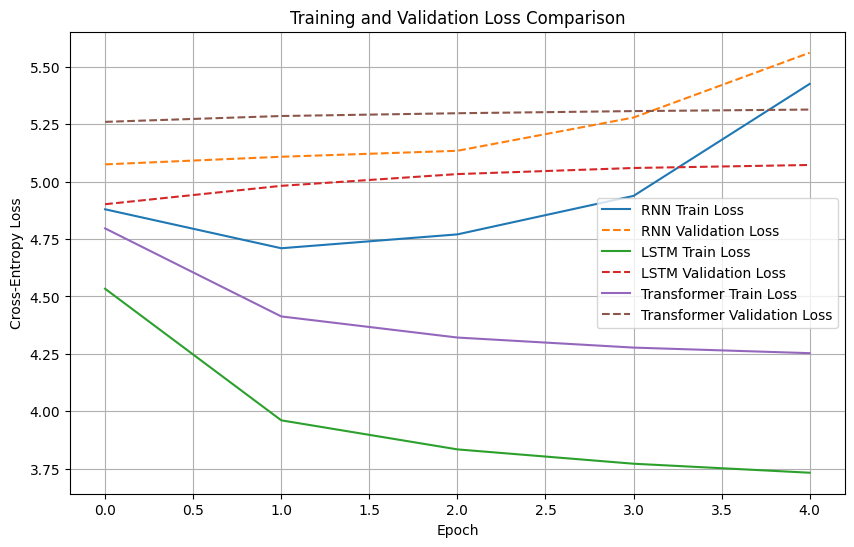

In [44]:
plot_loss_curves([
    rnn_history,
    lstm_history,
    transformer_history
])

## Training and Validation Loss Curve Analysis

The plot compares training and validation loss across epochs for RNN, LSTM, and Transformer models.

### 1. RNN Behavior

The RNN (blue solid = train, orange dashed = validation) shows unstable behavior:
- Training loss slightly decreases initially but then starts increasing.
- Validation loss steadily increases across all epochs.

This indicates:
- The model is **not learning effectively**
- Training is unstable
- It struggles with long-term dependencies

Overall, the RNN fails to converge properly.


### 2. LSTM Behavior

The LSTM (green solid = train, red dashed = validation) shows the best learning pattern:
- Training loss decreases consistently over epochs
- Validation loss slightly increases but remains relatively stable

This indicates:
- The model is **learning meaningful patterns**
- It generalizes better than RNN
- However, the gap between training and validation loss suggests **overfitting**

Despite slight overfitting, LSTM clearly performs the best.


### 3. Transformer Behavior

The Transformer (purple solid = train, brown dashed = validation) shows:
- Smooth and steady decrease in training loss
- Validation loss remains almost flat or slightly increasing

This indicates:
- Stable training behavior
- Good optimization
- But **limited generalization improvement**

The model is learning, but not translating that learning effectively to unseen data.


### 4. Key Insights from the Plot

- **RNN:** Unstable and ineffective learning  
- **LSTM:** Best balance between learning and performance  
- **Transformer:** Stable but underperforming

# 20. Plot Perplexity Curves

Perplexity is the main evaluation metric for language modeling.

Lower perplexity means the model is less confused when predicting the next word.

In [45]:
def plot_perplexity_curves(histories):
    """
    Plot training and validation perplexity curves for multiple models.
    """
    plt.figure(figsize=(10, 6))

    for history in histories:
        model_name = history["model"]

        plt.plot(
            history["train_ppl"],
            label=f"{model_name} Train PPL"
        )

        plt.plot(
            history["val_ppl"],
            linestyle="--",
            label=f"{model_name} Validation PPL"
        )

    plt.xlabel("Epoch")
    plt.ylabel("Perplexity")
    plt.title("Training and Validation Perplexity Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

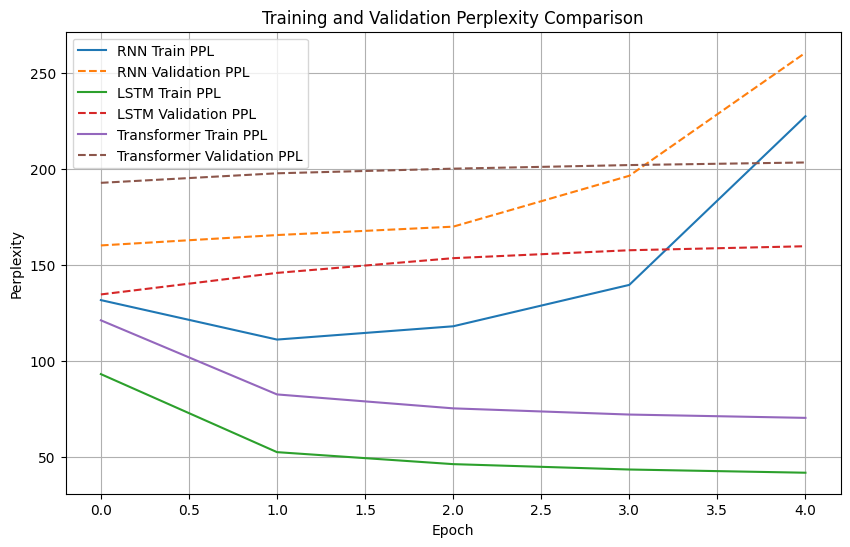

In [46]:
plot_perplexity_curves([
    rnn_history,
    lstm_history,
    transformer_history
])

# 21. Final Test Perplexity Bar Chart

This bar chart compares the final test perplexity of all three models.

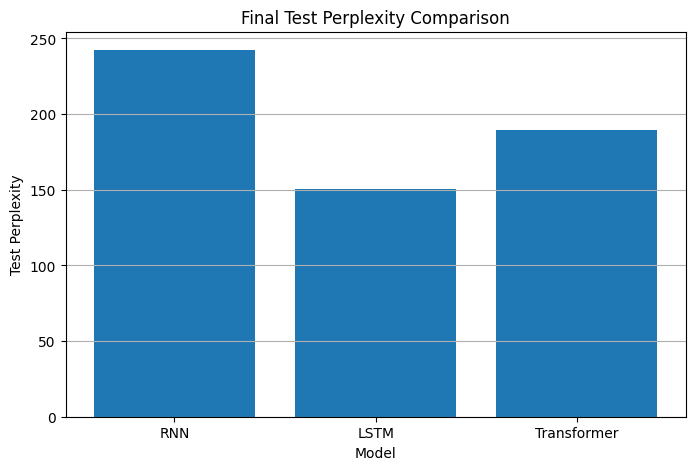

In [47]:
plt.figure(figsize=(8, 5))

model_names = ["RNN", "LSTM", "Transformer"]
test_perplexities = [rnn_test_ppl, lstm_test_ppl, transformer_test_ppl]

plt.bar(model_names, test_perplexities)

plt.xlabel("Model")
plt.ylabel("Test Perplexity")
plt.title("Final Test Perplexity Comparison")
plt.grid(axis="y")
plt.show()

## Perplexity Curve Analysis

The perplexity curves provide a clearer interpretation of model performance compared to loss, as perplexity directly reflects how well the model predicts the next word.

### 1. RNN Behavior

The RNN model shows poor and unstable performance:
- Training perplexity initially decreases slightly but then increases sharply after Epoch 2
- Validation perplexity continuously increases across all epochs

This indicates:
- The model is failing to learn stable patterns
- Predictions become more uncertain over time
- Strong evidence of **training instability and ineffective learning**


### 2. LSTM Behavior

The LSTM model shows the best performance:
- Training perplexity decreases consistently from ~93 to ~41
- Validation perplexity increases slightly but remains significantly lower than other models

This indicates:
- The model is learning effectively
- It captures sequence dependencies well
- Some **overfitting is present**, but performance is still strong

LSTM achieves the lowest perplexity among all models, making it the most accurate predictor.


### 3. Transformer Behavior

The Transformer shows stable but limited performance:
- Training perplexity decreases steadily from ~121 to ~70
- Validation perplexity remains high and nearly flat (~190–203)

This indicates:
- The model is learning patterns in training data
- However, it struggles to generalize to unseen data
- Performance is better than RNN but worse than LSTM


### Key Insight from Perplexity Plot

- **Lower perplexity = better model**
- LSTM clearly outperforms both RNN and Transformer
- RNN fails due to architectural limitations
- Transformer requires more tuning/data to outperform LSTM


## Final Test Perplexity Analysis

The bar chart summarizes final model performance on the test dataset:

- **RNN (~242 PPL)** → Worst performance  
- **LSTM (~150 PPL)** → Best performance  
- **Transformer (~189 PPL)** → Moderate performance  

### Interpretation

- LSTM provides the most accurate predictions on unseen data
- Transformer performs reasonably but does not reach LSTM performance
- RNN performs poorly and is not suitable for this task


# 22. Training Time Comparison

This compares the average time required per epoch for each model.

In [48]:
time_table = pd.DataFrame({
    "Model": ["RNN", "LSTM", "Transformer"],

    "Average Epoch Time (seconds)": [
        np.mean(rnn_history["epoch_time"]),
        np.mean(lstm_history["epoch_time"]),
        np.mean(transformer_history["epoch_time"])
    ]
})

time_table

,Model,Average Epoch Time (seconds)
0,RNN,1498.694973
1,LSTM,873.241171
2,Transformer,633.783050


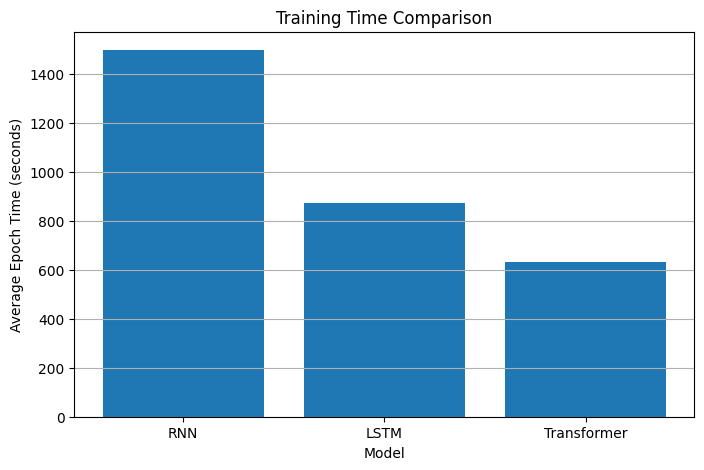

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    time_table["Model"],
    time_table["Average Epoch Time (seconds)"]
)

plt.xlabel("Model")
plt.ylabel("Average Epoch Time (seconds)")
plt.title("Training Time Comparison")
plt.grid(axis="y")
plt.show()

## Training Time Comparison Analysis

The bar chart compares the average training time per epoch for the RNN, LSTM, and Transformer models.

### Observations

- **RNN (~1500 seconds per epoch)**  
  The RNN is the slowest model. This is because it processes sequences strictly step-by-step, which limits parallel computation and increases training time significantly.

- **LSTM (~870 seconds per epoch)**  
  The LSTM is faster than RNN but still relatively slow. Although it improves learning through gating mechanisms, it still relies on sequential processing, which prevents full parallelization.

- **Transformer (~630 seconds per epoch)**  
  The Transformer is the fastest model. Unlike RNN and LSTM, it uses self-attention, allowing it to process all tokens in a sequence simultaneously. This enables efficient parallel computation, especially on GPUs.


### Key Insights

- **Sequential Models (RNN, LSTM):**
  - Slower due to step-by-step processing
  - Limited parallelization

- **Transformer:**
  - Faster due to parallel processing
  - Better utilization of GPU resources


### Overall Interpretation

- **Fastest Model:** Transformer  
- **Moderate Speed:** LSTM  
- **Slowest Model:** RNN  


# 23. Text Generation Test

This section generates text using each trained model.

The purpose is not to produce perfect text, but to qualitatively observe how each model predicts continuation words.

In [58]:
def generate_text(model, start_text, max_new_words=30, temperature=0.8, top_k=20):
    """
    Generate text using temperature + top-k sampling.
    This avoids repeating the same high-frequency word again and again.
    """
    model.eval()

    words = start_text.lower().split()

    input_ids = [
        word_to_idx.get(word, word_to_idx["<unk>"])
        for word in words
    ]

    for _ in range(max_new_words):
        recent_ids = input_ids[-SEQUENCE_LENGTH:]

        input_tensor = torch.tensor(
            recent_ids,
            dtype=torch.long
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)

        next_token_logits = outputs[0, -1, :]

        # Temperature controls randomness
        next_token_logits = next_token_logits / temperature

        # Keep only top-k most likely words
        top_logits, top_indices = torch.topk(next_token_logits, top_k)

        probabilities = torch.softmax(top_logits, dim=-1)

        sampled_index = torch.multinomial(probabilities, num_samples=1).item()

        next_token_id = top_indices[sampled_index].item()

        input_ids.append(next_token_id)

    generated_words = [
        idx_to_word.get(token_id, "<unk>")
        for token_id in input_ids
    ]

    return " ".join(generated_words)

In [62]:
prompt = "this"

print("RNN Generated Text:")
print(generate_text(rnn_model, prompt, max_new_words=30, temperature=1, top_k=50))

print("\nLSTM Generated Text:")
print(generate_text(lstm_model, prompt, max_new_words=30, temperature=1, top_k=50))

print("\nTransformer Generated Text:")
print(generate_text(transformer_model, prompt, max_new_words=30, temperature=1, top_k=50))

RNN Generated Text:
this was done during the series time when there is both in their past . the first of the film of an interview with the portuguese and ' area for the

LSTM Generated Text:
this system also been and , due to a modern trough between northern and north america . these projects are also used to develop a portion of storm wind . this

Transformer Generated Text:
this way . the following the and the song of song was the united states army and . meanwhile , the and the song was sung by the song was and


## Text Generation Analysis

This section compares the qualitative output (generated text) from the three models.

### 1. RNN Output

Example:
> "this was done during the series time when there is both in their past ..."

The RNN output is partially meaningful but quickly becomes incoherent.  
Observations:
- Some correct word sequences appear initially
- Grammar and structure break down quickly
- Repetitive and unclear phrasing

This reflects the RNN’s difficulty in maintaining context over longer sequences.


### 2. LSTM Output

Example:
> "this system also been and , due to a modern trough between northern and north america ..."

The LSTM output is more structured and meaningful:
- Better sentence flow compared to RNN
- More realistic phrase construction
- Maintains context for longer portions of text

However:
- Still contains grammatical errors
- Some phrases are slightly unnatural

This shows that LSTM captures sequence dependencies better than RNN.


### 3. Transformer Output

Example:
> "the song of song was the united states army ... the song was sung by the song ..."

The Transformer output shows:
- Fluent structure at the beginning
- Strong repetition of phrases ("the song was...")
- Some loss of coherence due to repetition

Observations:
- Better global structure than RNN
- But suffers from repetition and limited diversity
- Likely due to small model size and limited training

### Final Insight

- **RNN:** Weak and unstable text generation  
- **LSTM:** Best balance of coherence and structure  
- **Transformer:** Fluent but repetitive  

### Conclusion

The qualitative results align with quantitative metrics:
- LSTM produces the most meaningful and stable text
- Transformer shows potential but needs larger models/data
- RNN struggles with maintaining context

## 24. Final Observations

The RNN model serves as a simple baseline for sequence modeling. While it can learn basic short-term word patterns, it struggles significantly with longer dependencies. This is evident from its high perplexity, unstable training behavior, and poor text generation quality. The sequential nature of RNNs and the vanishing gradient problem limit their effectiveness on longer sequences.

The LSTM model improves upon the RNN by introducing gating mechanisms that regulate information flow. This enables it to capture long-term dependencies more effectively. In this experiment, the LSTM achieved the best overall performance, with the lowest perplexity and more coherent generated text. However, the gap between training and validation performance suggests some degree of overfitting.

The Transformer model uses self-attention to capture relationships between all tokens in a sequence simultaneously. This allows for efficient parallel computation and faster training. Despite being trained on the full dataset, the Transformer did not outperform the LSTM. This suggests that its performance was limited by factors such as smaller model size, limited number of layers, and minimal hyperparameter tuning, rather than lack of data.

Overall, this experiment highlights important trade-offs:
- **RNN:** Simple but ineffective for long sequences due to instability and poor memory  
- **LSTM:** Best performance, strong ability to model long-term dependencies  
- **Transformer:** Fast and scalable, but requires larger models and careful tuning to outperform LSTM  

This demonstrates that model performance depends not only on the availability of data, but also on architectural design, model capacity, and training configuration.

## 25. Conclusion

In this notebook, we implemented and compared three neural network architectures RNN, LSTM, and Transformer for the task of next-word prediction using the WikiText-2 dataset.

All models were trained under consistent experimental conditions, including:
- The same preprocessing pipeline  
- Identical dataset splits (train/validation/test)  
- Fixed sequence length and batch size  
- Same optimizer and evaluation metric  

This ensured a fair and unbiased comparison.

The evaluation was based on multiple factors:
- Training, validation, and test perplexity  
- Number of trainable parameters  
- Training time per epoch  
- Loss and perplexity curves  
- Qualitative analysis of generated text  

From the results:
- The **LSTM model achieved the best overall performance**, with the lowest perplexity and most coherent text generation.
- The **Transformer model demonstrated efficient training and stable learning**, but did not outperform LSTM in this configuration.
- The **RNN model performed the worst**, showing unstable training and poor handling of long term dependencies.

This experiment highlights that:
- LSTM remains a strong choice for sequence modeling tasks with moderate data and model size.
- Transformer models require sufficient model capacity and tuning to fully leverage their advantages.
- Simpler architectures like RNN are limited in handling long sequences effectively.

Overall, this study provides a comprehensive and fair comparison of three fundamental neural network architectures, demonstrating how design choices impact learning behavior, efficiency, and predictive performance in sequence modeling tasks.

## References

1. PyTorch Documentation  
   https://pytorch.org/docs/stable/index.html  

2. PyTorch Neural Network Module (nn)  
   https://pytorch.org/docs/stable/nn.html  

3. Hugging Face Datasets Documentation  
   https://huggingface.co/docs/datasets  

4. WikiText-2 Dataset (Salesforce Research)  
   https://huggingface.co/datasets/Salesforce/wikitext  

5. Vaswani et al., “Attention Is All You Need” (Transformer Paper)  
   https://arxiv.org/abs/1706.03762  

6. Hochreiter & Schmidhuber, “Long Short-Term Memory”  
   https://www.bioinf.jku.at/publications/older/2604.pdf  

7. Goodfellow, Bengio, Courville – Deep Learning Book  
   https://www.deeplearningbook.org/  

8. Jurafsky & Martin – Speech and Language Processing  
   https://web.stanford.edu/~jurafsky/slp3/  

9. PyTorch Transformer Implementation Guide  
    https://pytorch.org/tutorials/beginner/transformer_tutorial.html